In [1]:
import phobos
arch = phobos.Arch6()

✅ BMC lib found. Running in control mode.


Turned off injection segments: [138, 137, 136, 135]


Calibrating injection:   0%|          | 0/4 [00:00<?, ?it/s]

Turned off injection segments: [138, 137, 136, 135]


Calibrating injection:  25%|██▌       | 1/4 [00:09<00:27,  9.05s/it]

[calibrate_injection] seg=138: centroid->(tip,tilt)=(-0.175,1.150) mrad; snapped=(-0.105,1.158); flux_max=8.8e+04
Turned off injection segments: [138, 137, 136, 135]


...

[calibrate_injection] seg=137: centroid->(tip,tilt)=(0.283,1.090) mrad; snapped=(0.316,1.158); flux_max=1.06e+05
Turned off injection segments: [138, 137, 136, 135]


Calibrating injection:  75%|███████▌  | 3/4 [00:27<00:09,  9.04s/it]

[calibrate_injection] seg=136: centroid->(tip,tilt)=(0.545,0.943) mrad; snapped=(0.526,0.947); flux_max=9.08e+04
Turned off injection segments: [138, 137, 136, 135]


Calibrating injection: 100%|██████████| 4/4 [00:36<00:00,  9.05s/it]

[calibrate_injection] seg=135: centroid->(tip,tilt)=(0.654,0.940) mrad; snapped=(0.737,0.947); flux_max=1.08e+05
[calibrate_injection] seg=137: balanced on ray to match ref_flux=8.8e+04 -> (tip,tilt)=(0.222,0.813) mrad; flux_bal=8.8e+04
[calibrate_injection] seg=136: balanced on ray to match ref_flux=8.8e+04 -> (tip,tilt)=(0.448,0.807) mrad; flux_bal=8.8e+04
[calibrate_injection] seg=135: balanced on ray to match ref_flux=8.8e+04 -> (tip,tilt)=(0.511,0.658) mrad; flux_bal=8.8e+04


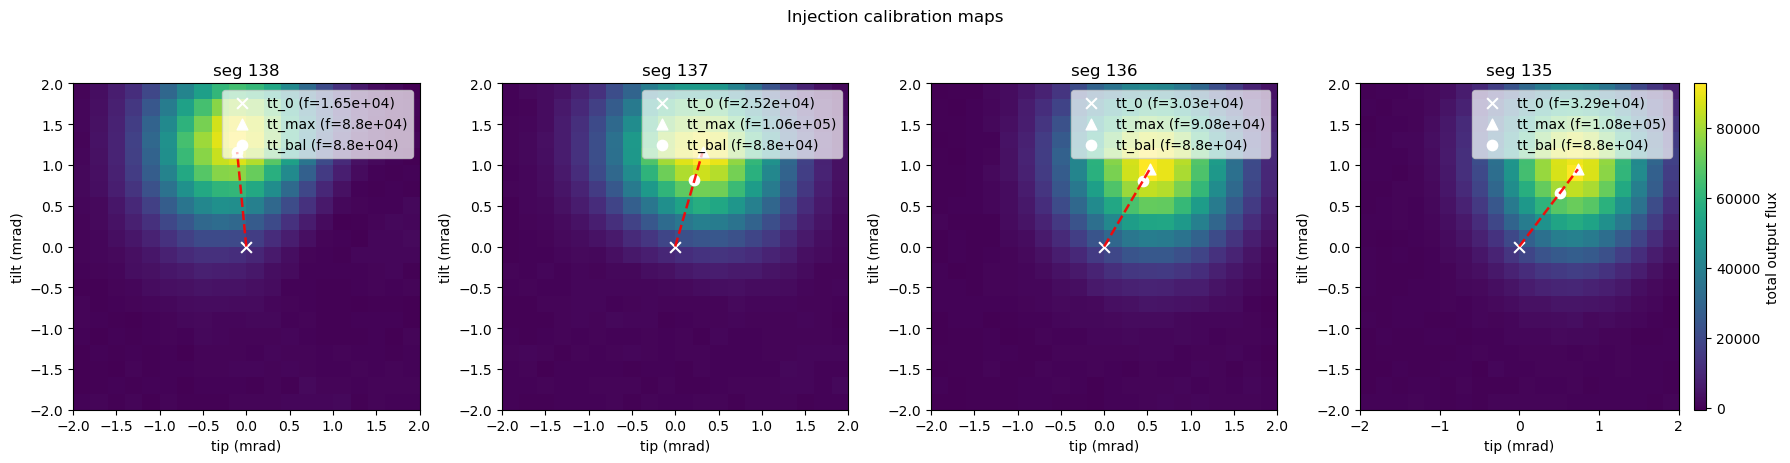

✅ Injection calibration saved to config under dm.ptt_max and dm.ptt_balanced


{'max': {'138': [-1150.0, -0.10526315789473695, 1.1578947368421053],
  '137': [-1150.0, 0.3157894736842106, 1.1578947368421053],
  '136': [-1150.0, 0.5263157894736841, 0.9473684210526314],
  '135': [-1150.0, 0.7368421052631575, 0.9473684210526314]},
 'balanced': {'138': [-1150.0, -0.10526315789473695, 1.1578947368421053],
  '137': [-1150.0, 0.22181882493705918, 0.8133356914358835],
  '136': [-1150.0, 0.44824939642927386, 0.8068489135726931],
  '135': [-1150.0, 0.5113921086150446, 0.6575041396479147]}}

In [27]:
phobos.DM().calibrate_injection(plot=True, verbose=True)

In [28]:
phobos.DM().balanced()

Applied BALANCED injection calibration on segments: [138, 137, 136, 135]


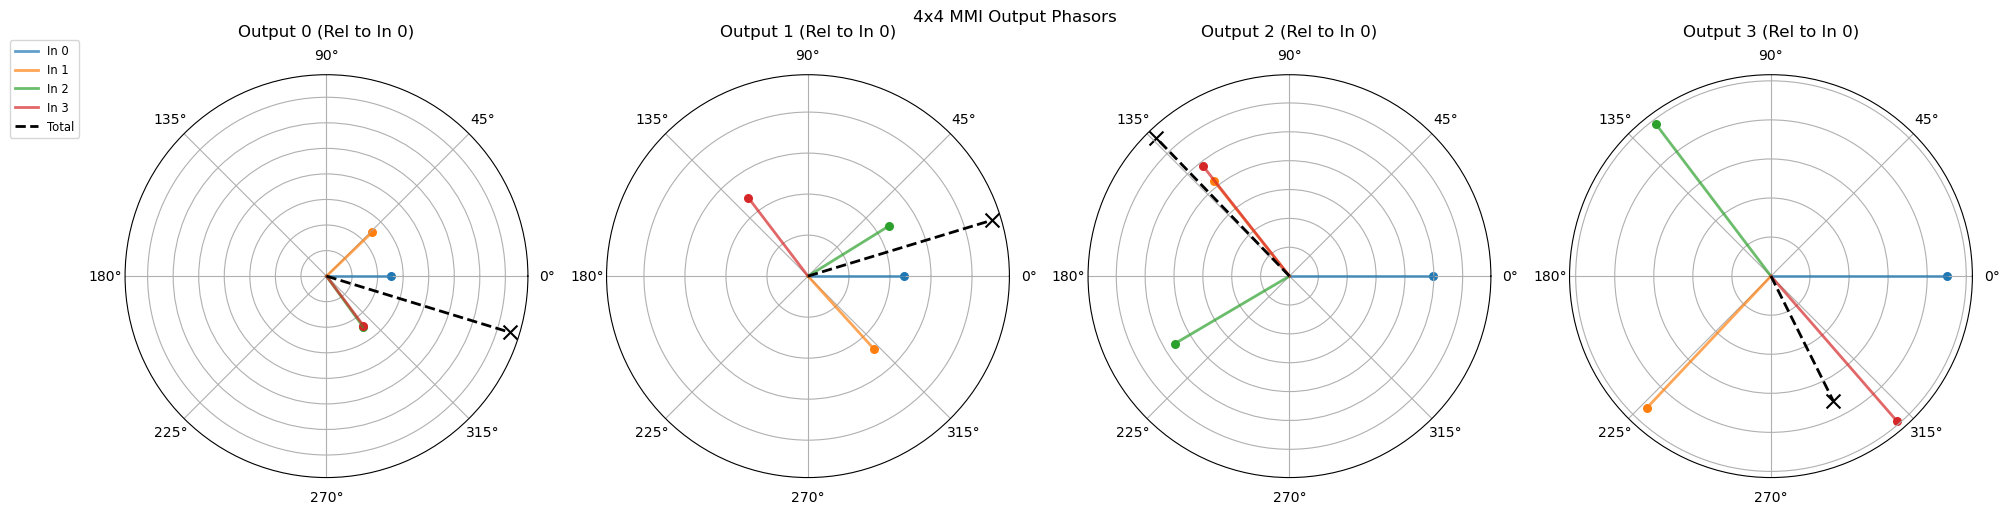

🚀 No data path provided. Running characterization...
🔬 Starting full characterization of 4-Port MMI Active...
   Inputs: 4, Outputs: 4, Shifters: 4
   Save directory: generated/architecture_characterization/4-Port_MMI_Active/20260128_155539

📊 Scanning with 1 input(s) active: [1]
Turned off injection segments: [138, 137, 136, 135]
Flattened injection segments: [138]
  [1/60] Shifter 17 (TOPA 1/4)
     ✅ Scan stored: n1_inputs_1_shifter17 (fits: 4/4)
  [2/60] Shifter 18 (TOPA 2/4)
     ✅ Scan stored: n1_inputs_1_shifter17 (fits: 4/4)
  [2/60] Shifter 18 (TOPA 2/4)
     ✅ Scan stored: n1_inputs_1_shifter18 (fits: 4/4)
  [3/60] Shifter 19 (TOPA 3/4)
     ✅ Scan stored: n1_inputs_1_shifter18 (fits: 4/4)
  [3/60] Shifter 19 (TOPA 3/4)
     ✅ Scan stored: n1_inputs_1_shifter19 (fits: 4/4)
  [4/60] Shifter 20 (TOPA 4/4)
     ✅ Scan stored: n1_inputs_1_shifter19 (fits: 4/4)
  [4/60] Shifter 20 (TOPA 4/4)
     ✅ Scan stored: n1_inputs_1_shifter20 (fits: 4/4)

📊 Scanning with 1 input(s) active: 

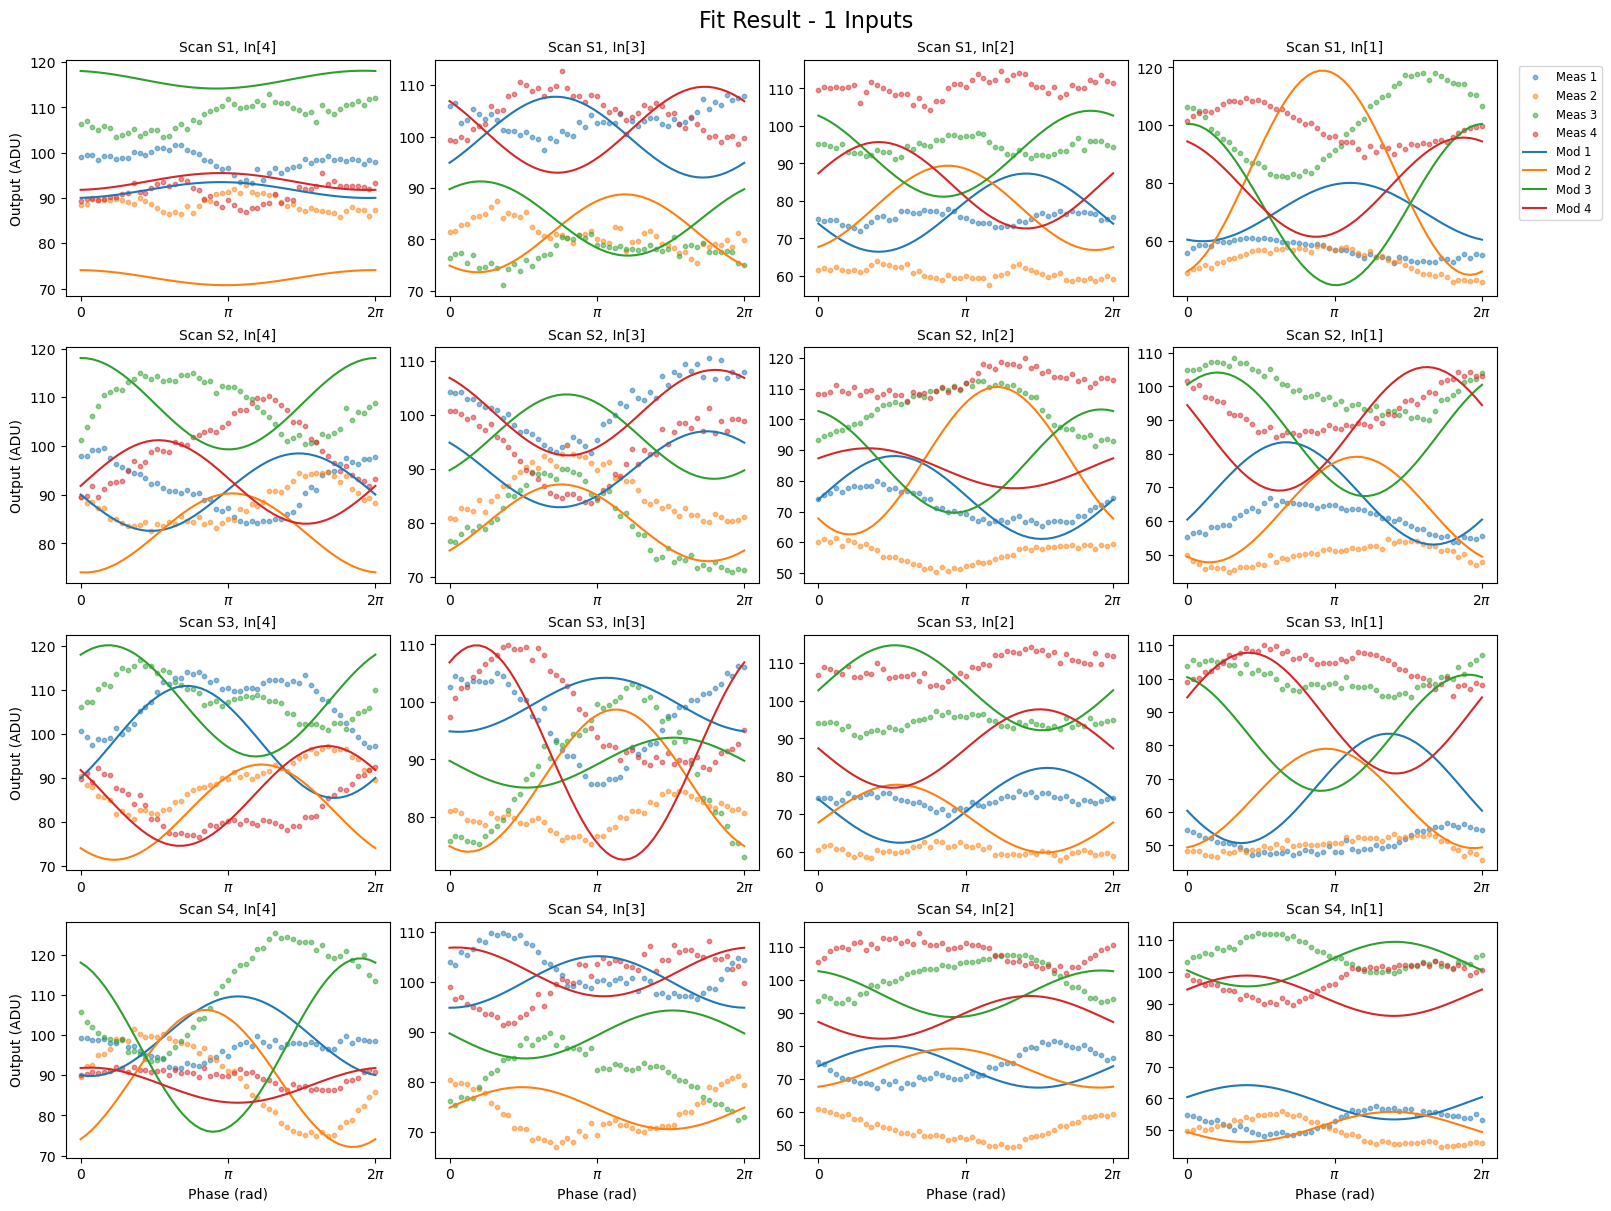

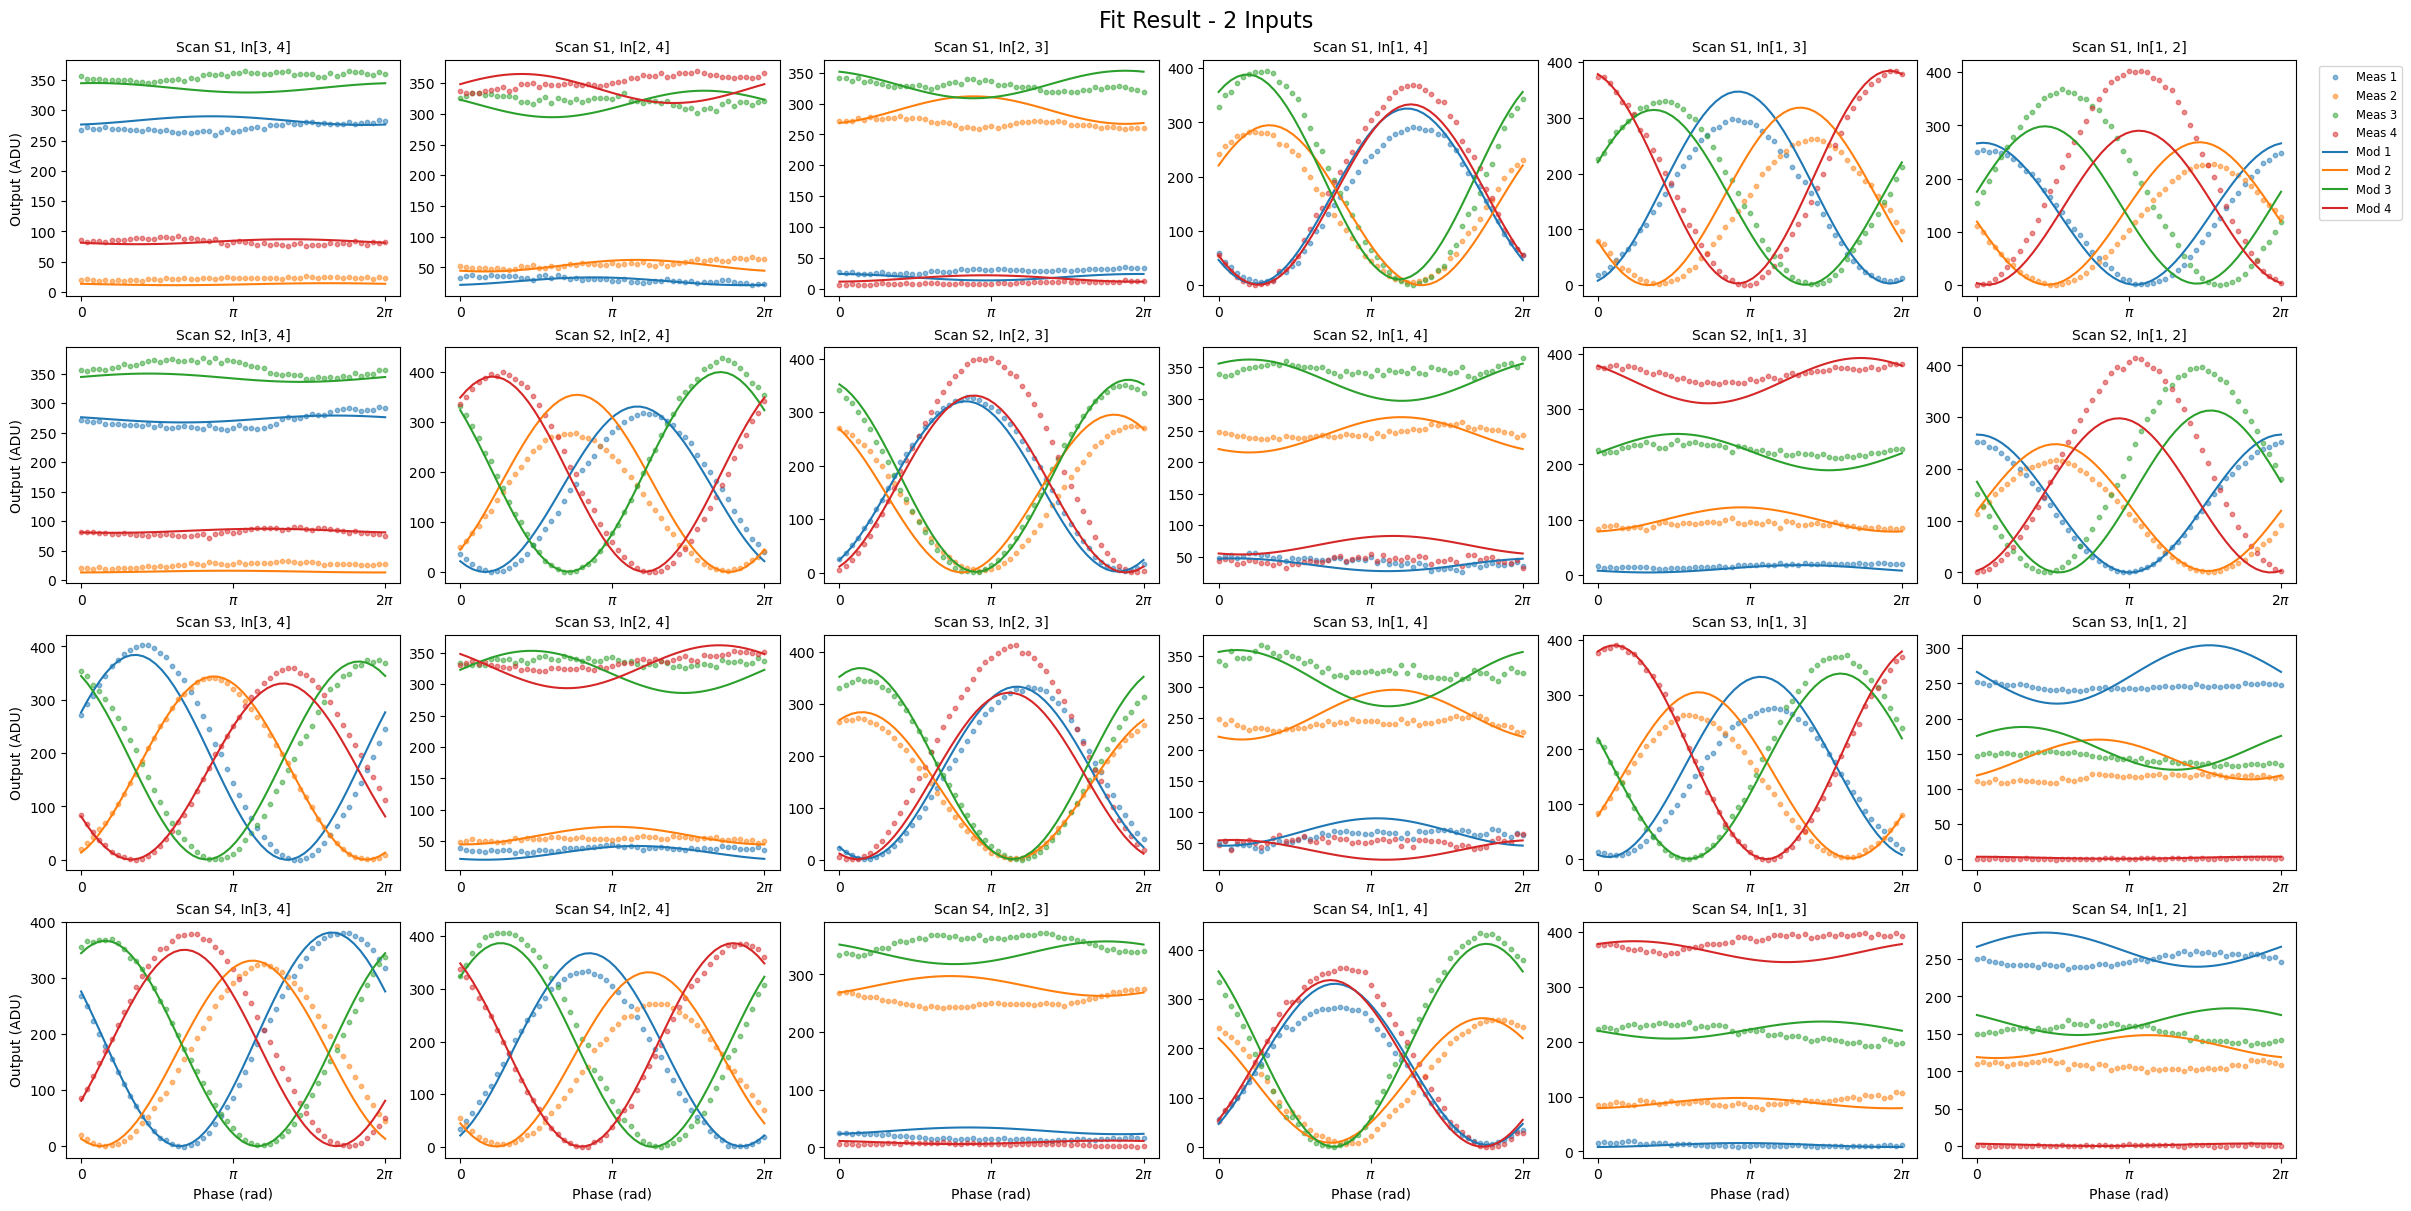

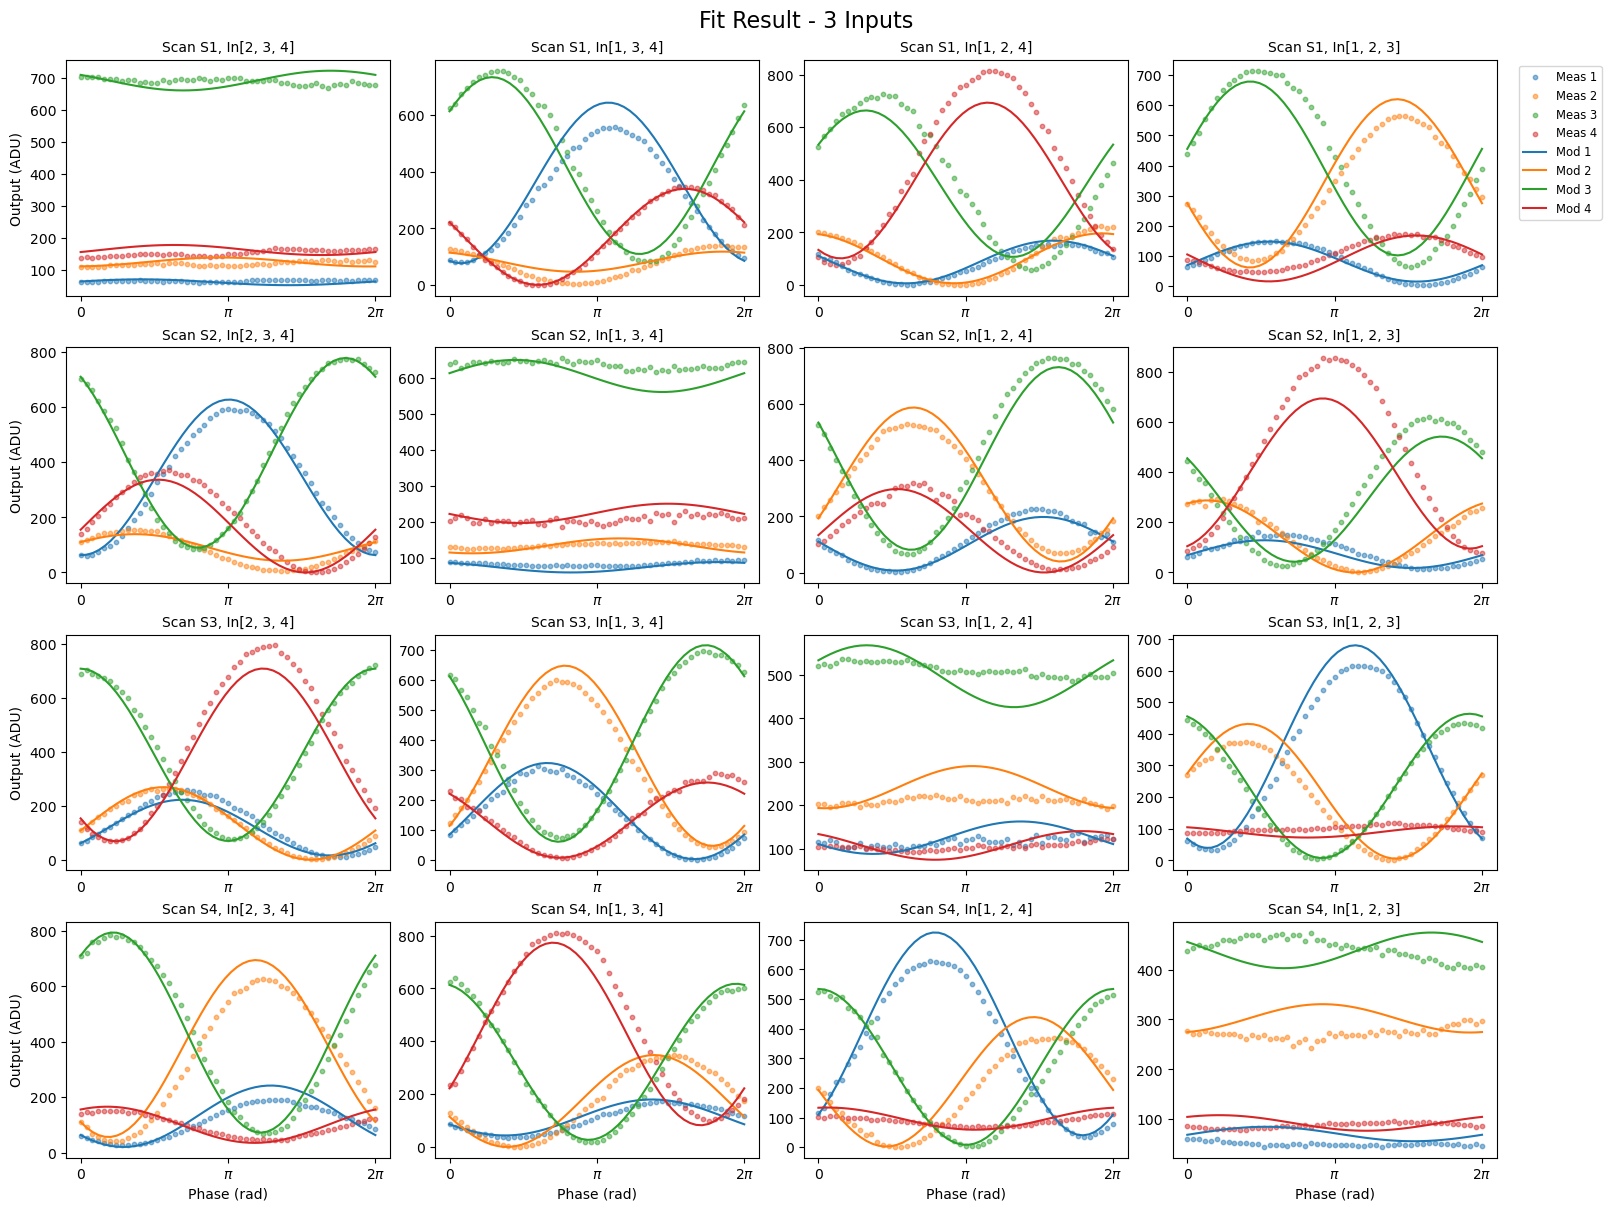

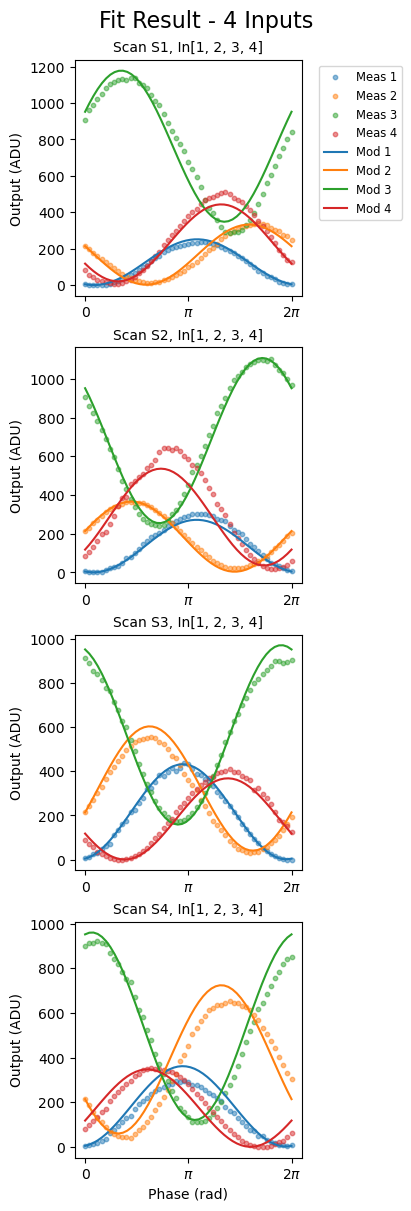

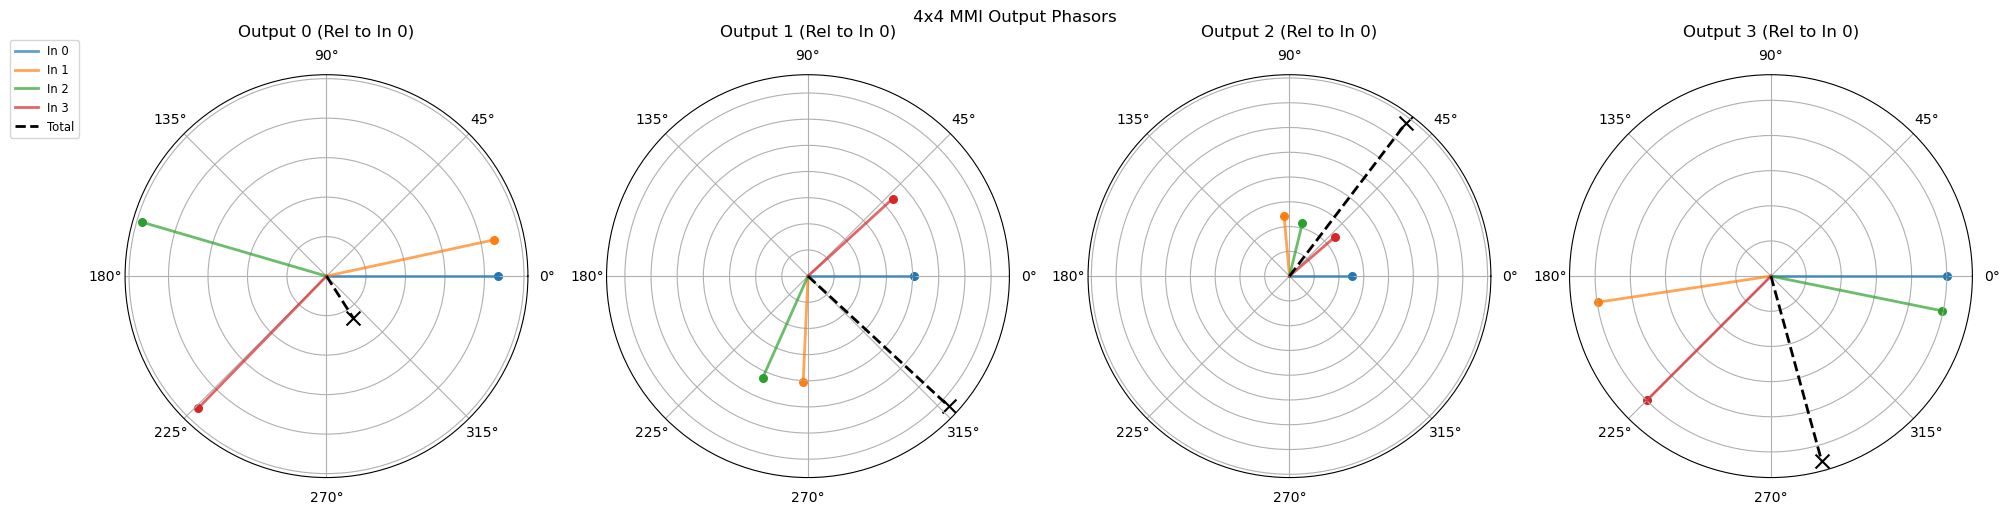

array([[ 0.43264831+0.02220442j,  0.41915892+0.11362236j,
        -0.47259995+0.11232559j, -0.3066527 -0.34974666j],
       [-0.21369303+0.34516326j,  0.35412152+0.19759492j,
         0.42209285+0.05756926j, -0.42281201+0.1197379j ],
       [ 0.28040724-0.42217536j,  0.37797793+0.30285721j,
         0.41829536+0.15164506j,  0.46931665-0.13162657j],
       [-0.47171218+0.17090984j,  0.48789242-0.09791738j,
        -0.42469371+0.25905879j,  0.45216043+0.2118372j ]])

In [4]:
phobos.Arch6().predict_phasors()
outs = arch.phase_calibration()
outs = arch.solve_matrix()
phobos.Arch6().predict_phasors()

#outs = arch.solve_matrix(data_path='./generated/architecture_characterization/4-Port_MMI_Active/20251208_164250/characterization_data.npz')

In [5]:
from IPython.display import display, Math
import numpy as np

def format_complex(val):
    alpha = np.abs(val)
    if alpha < 1e-10:
        return "0"
    beta = np.angle(val) / np.pi
    return f"{alpha:.2f}e^{{i({beta:.2f})\\pi}}"

def display_results(data, label=None):
    if label:
        print(label)
        
    # Standardize to 2D for loop
    if data.ndim == 1:
        matrix = data.reshape(1, -1) # Display as row vector
    else:
        matrix = data

    latex_rows = []
    for row in matrix:
        formatted_elements = [format_complex(val) for val in row]
        latex_rows.append(" & ".join(formatted_elements))

    latex_str = r"\begin{pmatrix} " + r" \\ ".join(latex_rows) + r" \end{pmatrix}"
    display(Math(latex_str))

    # Norm Check
    if data.ndim == 2: # Matrix
        norm = np.linalg.norm(data, 2)
        print(f"Spectral Norm: {norm:.4f}")
        if norm <= 1.001:
             print("Energy conservation check: Pass (<= 1)")
        else:
             print("Energy conservation check: Fail (> 1)")
    elif data.ndim == 1: # Vector
        norm = np.linalg.norm(data)
        print(f"L2 Norm: {norm:.4f}")
    print("-"*30)

# Display Results
if 'cost' in outs:
    print(f"Optimization Cost: {outs['cost']:.4e}\n")

vectors = ['I_ON', 'I_OFF']
for key in vectors:
    if key in outs:
        display_results(outs[key], label=f"{key} (Control Vector):")

matrices = ['A', 'C_before']
for key in matrices:
    if key in outs:
        display_results(outs[key], label=f"Matrix {key}:")


Optimization Cost: 6.3927e+04

I_ON (Control Vector):


<IPython.core.display.Math object>

L2 Norm: 39.8124
------------------------------
I_OFF (Control Vector):


<IPython.core.display.Math object>

L2 Norm: 1.2682
------------------------------
Matrix A:


<IPython.core.display.Math object>

Spectral Norm: 1.0000
Energy conservation check: Pass (<= 1)
------------------------------
Matrix C_before:


<IPython.core.display.Math object>

Spectral Norm: 1.0000
Energy conservation check: Pass (<= 1)
------------------------------


In [6]:

import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# Retrieve A from previous results
A_rec = outs['A']

def plot_phasors(phi1, phi2, phi3, phi4):
    # Phases in radians
    phases = np.array([phi1, phi2, phi3, phi4])
    
    # Input vector v = P @ [1, 1, 1, 1] = [exp(1j*phi1), ...]
    v = np.exp(1j * phases * np.pi)
    
    # Create Figure
    fig, axs = plt.subplots(1, 4, subplot_kw={'projection': 'polar'}, figsize=(20, 5))
    fig.suptitle('Phasor Contributions per Output (Interactive Phases)', fontsize=16, y=1.1)

    labels = ['In 1', 'In 2', 'In 3', 'In 4']
    colors = ['red', 'green', 'blue', 'orange']

    for k in range(4): # Output k
        ax = axs[k]
        ax.set_title(f"Output {k+1}", va='bottom')
        
        resultant = 0
        
        for j in range(4): # Input j
            # Contribution: A_kj * v_j
            val = A_rec[k, j] * v[j]
            resultant += val
            
            theta = np.angle(val)
            r = np.abs(val)
            
            # Plot individual contribution vector
            ax.plot([0, theta], [0, r], color=colors[j], label=labels[j] if k==0 else "", alpha=0.7, linewidth=1.5)
            ax.plot([theta], [r], 'o', color=colors[j], markersize=5)

        # Plot Resultant Vector
        theta_res = np.angle(resultant)
        r_res = np.abs(resultant)
        ax.plot([0, theta_res], [0, r_res], color='black', linewidth=2.5, linestyle='-', label='Sum' if k==0 else "")
        
        # Fixed scale for stability
        ax.set_ylim(0, 1.5)
        ax.grid(True)

    # Standard Legend
    fig.legend(loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.1))
    plt.tight_layout()
    plt.show()

# Widgets
style = {'description_width': 'initial'}
sliders = [
    widgets.FloatSlider(min=0, max=2, step=0.01, value=0, description=f'Phase {i+1} (rad)', style=style, layout=widgets.Layout(width='300px')) 
    for i in range(4)
]

ui = widgets.VBox(sliders)
out_plot = widgets.interactive_output(plot_phasors, {'phi1': sliders[0], 'phi2': sliders[1], 'phi3': sliders[2], 'phi4': sliders[3]})

display(ui, out_plot)

Output()

🧬 Starting Genetic Calibration for Arch6...
✅ Genetic calibration complete in 44 iterations.
✅ Genetic calibration complete in 44 iterations.


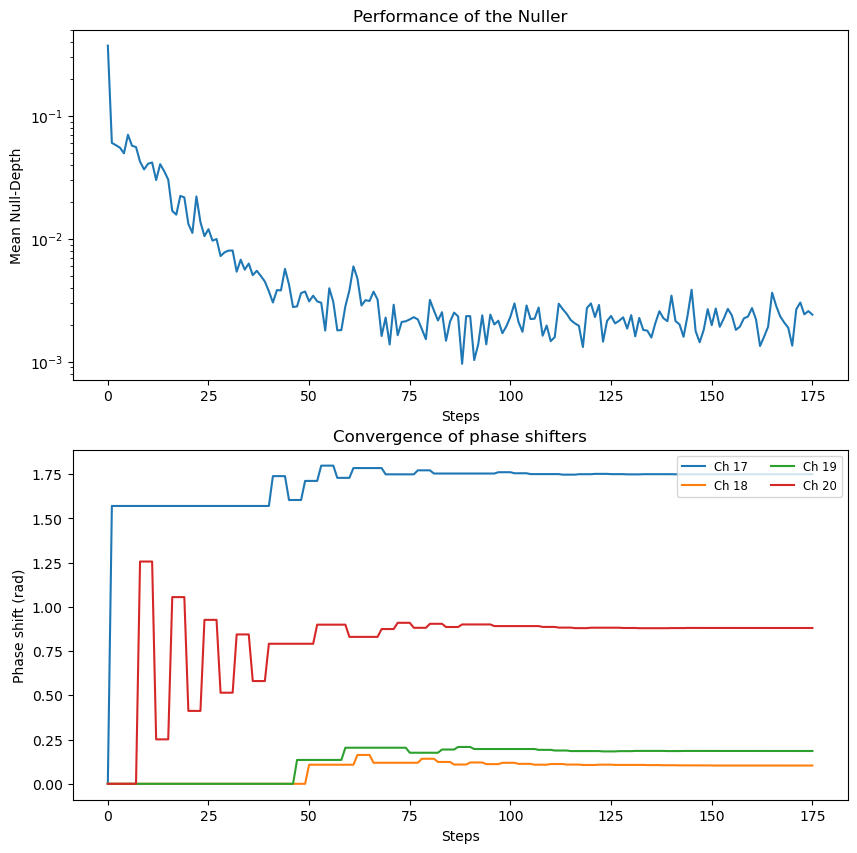

In [29]:
phases, history = phobos.Arch6().null_calibration_gen(bright_output=2, plot=True, return_history=True)

In [30]:
phobos.Arch6().set_phases(phases)
phobos.Cred3().get_outputs(flux_mode='sum')

array([   284.83410645,    575.51818848, 214419.578125  ,    726.15466309])

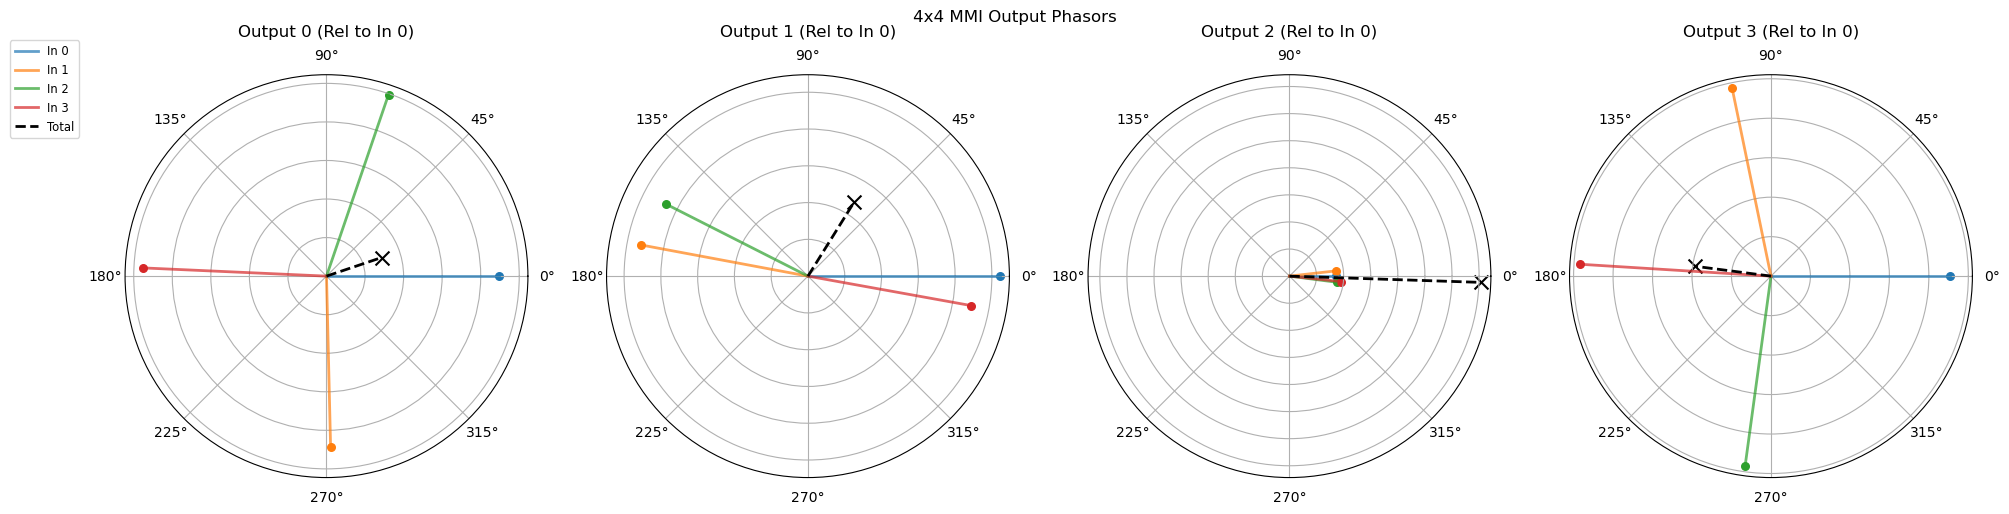

array([[-0.11607174+0.43243774j,  0.4260181 +0.12539806j,
        -0.49650949+0.03331253j,  0.10282546-0.46541701j],
       [-0.37089955-0.36679512j,  0.38201438+0.25865348j,
         0.41295226+0.13240257j, -0.37185986-0.25506453j],
       [ 0.33119988+0.2683552j ,  0.3048319 +0.31000372j,
         0.37258544+0.2297167j ,  0.40261838+0.26092604j],
       [-0.0961938 -0.44443389j,  0.48597154-0.00456586j,
        -0.45621973+0.16574152j,  0.13199941+0.46716374j]])

In [31]:
phobos.Arch6().predict_phasors(injected_phases=phases)

/home/photonics/miniconda3/envs/photonic/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/photonics/miniconda3/envs/photonic/lib/python3.11/site-packages/numpy/lib/histograms.py:839: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
/home/photonics/miniconda3/envs/photonic/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7127: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


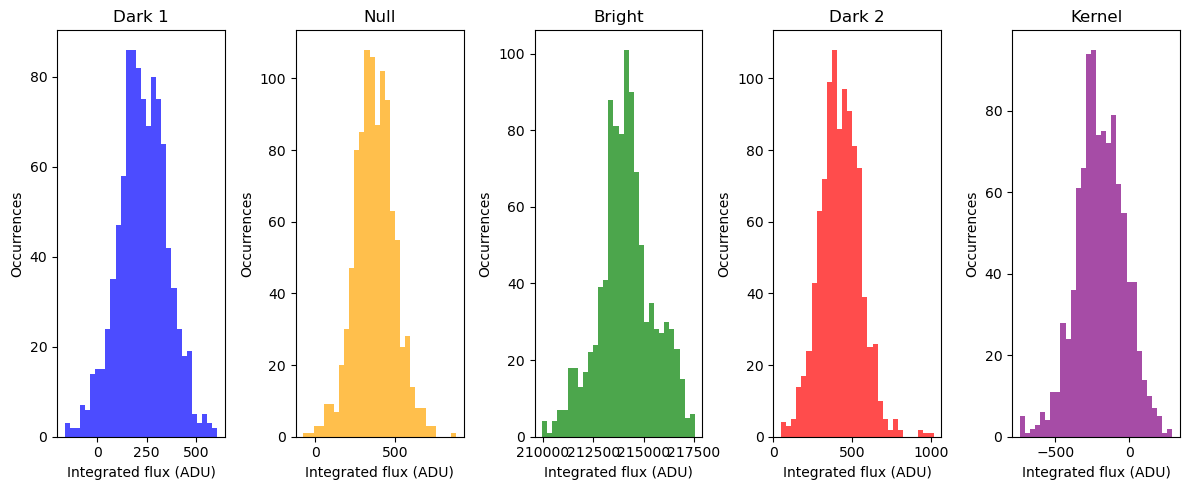

Median of null depth:
   Null: 1.74e-03
   Dark 1: 1.05e-03
   Dark 2: 1.97e-03
   Kernel: 9.66e-04


In [32]:
phobos.Arch6().set_phases(phases)

N = 1000

outs = np.zeros((N, 4), dtype=complex)
kernel = np.zeros((N,), dtype=complex)
for i in range(N):
    outs[i] = phobos.Cred3().get_outputs(flux_mode='sum')
    kernel[i] = outs[i,0] - outs[i,3]

# Histograms
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 5, figsize=(12, 5), tight_layout=True)
axs[0].hist(outs[:,0], bins=30, color='blue', alpha=0.7)
axs[0].set_title('Dark 1')
axs[1].hist(outs[:,1], bins=30, color='orange', alpha=0.7)
axs[1].set_title('Null')
axs[2].hist(outs[:,2], bins=30, color='green', alpha=0.7)
axs[2].set_title('Bright')
axs[3].hist(outs[:,3], bins=30, color='red', alpha=0.7)
axs[3].set_title('Dark 2')
axs[4].hist(kernel, bins=30, color='purple', alpha=0.7)
axs[4].set_title('Kernel')
for ax in axs:
    ax.set_xlabel('Integrated flux (ADU)')
    ax.set_ylabel('Occurrences')
plt.show()

print("Median of null depth:")
bright = np.median(np.abs(outs[:,2]))
null = np.median(np.abs(outs[:,1]))
dark_1 = np.median(np.abs(outs[:,0]))
dark_2 = np.median(np.abs(outs[:,3]))
kernel_med = np.median(np.abs(kernel))
print(f"   Null: {null/bright:.2e}")
print(f"   Dark 1: {dark_1/bright:.2e}")
print(f"   Dark 2: {dark_2/bright:.2e}")
print(f"   Kernel: {kernel_med/bright:.2e}")

In [26]:
phobos.XPOW().turn_off()
phobos.DM().flat()  # Reset injection segments to (piston, tip, tilt) = (0, 0, 0)

Flattened injection segments: [138, 137, 136, 135]
